# ECE501 Digital Image Processing
## Project 8 – Vehicle Orientation Estimation Using Conventional Image Processing

WEEK 3 — VEHICLE ORIENTATION ESTIMATION USING CONVENTIONAL IMAGE PROCESSING

Objective:
Compare three classical image-processing methods for vehicle orientation estimation:

1. PCA-based orientation estimation
2. Hough Transform-based orientation estimation
3. Contour-based orientation estimation

Experiment:
1. Test the complete pipeline on one vehicle.
2. Verify vehicle extraction and ground-truth orientation.
3. Apply the same preprocessing to the vehicle.
4. Estimate orientation using PCA, Hough and Contour methods.
5. After successful single-image validation, select exactly 100 different images.
6. Extract one valid vehicle from each image.
7. Run all three methods on the same 100 vehicles.
8. Calculate angular error.
9. Compare overall and class-wise performance.
10. Save tables, graphs and results for the Week-3 submission.

Important:
The OBB annotation is used only to locate the vehicle crop.
The orientation prediction is calculated from the vehicle image using conventional image-processing methods.


In [4]:
# =========================================================
# WEEK 3 - CELL 2
# IMPORT ALL REQUIRED LIBRARIES
# =========================================================

import os
import io
import math
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

import fsspec

from google.colab import drive


print("All libraries imported successfully.")

All libraries imported successfully.


GOOGLE DRIVE SETUP

The original training annotation ZIP is stored in Google Drive.

The large training image ZIP is not downloaded again. It will be accessed remotely from Zenodo.

Google Drive will also be used to permanently save the Week-3 results.

In [5]:
# =========================================================
# WEEK 3 - CELL 4
# MOUNT GOOGLE DRIVE
# =========================================================

drive.mount("/content/drive")


# Main project/data folder in Google Drive
DATA_DIR = Path(
    "/content/drive/MyDrive/ECE501_DRASHTI"
)


# Annotation ZIP
LABEL_ZIP_PATH = (
    DATA_DIR /
    "train_original.zip"
)


# Optional metadata CSV
FRAMEWISE_CSV_PATH = (
    DATA_DIR /
    "DRASHTI-HaOBB_framewise_info.csv"
)


print("\nChecking Google Drive files...\n")


print(
    "train_original.zip:",
    "FOUND"
    if LABEL_ZIP_PATH.exists()
    else "NOT FOUND"
)


print(
    "framewise CSV:",
    "FOUND"
    if FRAMEWISE_CSV_PATH.exists()
    else "NOT FOUND"
)


if not LABEL_ZIP_PATH.exists():

    raise FileNotFoundError(
        "\ntrain_original.zip was not found.\n"
        "Expected location:\n"
        f"{LABEL_ZIP_PATH}"
    )


print(
    "\nDrive setup completed successfully."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Checking Google Drive files...

train_original.zip: FOUND
framewise CSV: FOUND

Drive setup completed successfully.


VEHICLE CLASS DEFINITIONS

DRASHTI-HaOBB uses 14 vehicle classes.

The annotation files encountered in the project contain the class name directly, for example:
Truck, SUV, Bus, Sedan, etc.

The code below supports both class names and numeric class IDs so that the parser remains robust.

In [6]:
# =========================================================
# WEEK 3 - CELL 6
# VEHICLE CLASS DEFINITIONS
# =========================================================

CLASS_NAMES = [
    "Auto3WCargo",
    "AutoRicksaw",
    "Bus",
    "Container",
    "Mixer",
    "MotorCycle",
    "PickUp",
    "SUV",
    "Sedan",
    "Tanker",
    "Tipper",
    "Trailer",
    "Truck",
    "Van"
]


ID_TO_CLASS = {
    index: name
    for index, name in enumerate(
        CLASS_NAMES
    )
}


CLASS_TO_ID = {
    name: index
    for index, name in enumerate(
        CLASS_NAMES
    )
}


print("Vehicle class mapping:\n")

for class_id, class_name in ID_TO_CLASS.items():

    print(
        f"{class_id:2d} -> {class_name}"
    )

Vehicle class mapping:

 0 -> Auto3WCargo
 1 -> AutoRicksaw
 2 -> Bus
 3 -> Container
 4 -> Mixer
 5 -> MotorCycle
 6 -> PickUp
 7 -> SUV
 8 -> Sedan
 9 -> Tanker
10 -> Tipper
11 -> Trailer
12 -> Truck
13 -> Van


GROUND-TRUTH ORIENTATION CONVERSION

The DRASHTI-HaOBB dataset provides a heading angle.

For this project, the heading is converted to an undirected orientation represented between 0 and 90 degrees.

The original heading value is retained for reference.

In [7]:
# =========================================================
# WEEK 3 - CELL 8
# HEADING -> 0-90 DEGREE ORIENTATION
# =========================================================

def heading_to_orientation(
    heading
):
    """
    Convert heading angle into an
    undirected 0-90 degree orientation.
    """

    theta = (
        float(heading)
        % 180.0
    )

    if theta > 90.0:

        theta = (
            180.0
            - theta
        )

    return theta


# Test the conversion
test_angles = [
    0,
    30,
    90,
    120,
    180,
    225,
    270,
    315
]


print(
    "Heading -> Orientation\n"
)

for angle in test_angles:

    print(
        f"{angle:3d}° -> "
        f"{heading_to_orientation(angle):.1f}°"
    )

Heading -> Orientation

  0° -> 0.0°
 30° -> 30.0°
 90° -> 90.0°
120° -> 60.0°
180° -> 0.0°
225° -> 45.0°
270° -> 90.0°
315° -> 45.0°


OPEN THE ORIGINAL TRAINING ANNOTATION ZIP

The annotation ZIP is small compared with the image ZIP, so it can be opened directly from Google Drive.

Only annotation filenames are listed first.

We will NOT parse every annotation file.

In [8]:
# =========================================================
# WEEK 3 - CELL 10
# OPEN TRAINING ANNOTATION ZIP
# =========================================================

label_zip = zipfile.ZipFile(
    LABEL_ZIP_PATH,
    mode="r"
)


# List only TXT annotation files
all_label_members = [
    name
    for name in label_zip.namelist()
    if name.lower().endswith(".txt")
]


print(
    "Number of annotation files found:",
    len(all_label_members)
)


print("\nFirst 10 annotation files:\n")

for name in all_label_members[:10]:

    print(name)

Number of annotation files found: 16571

First 10 annotation files:

train_original/008s_Z0OT_vtne.txt
train_original/00KF_8PHt_jJ8M.txt
train_original/00sq_cBbT_X84h.txt
train_original/00XD_3rEO_4KVW.txt
train_original/01AM_E3Lm_fKAO.txt
train_original/01Bv_6OpA_c89J.txt
train_original/01hA_C6z3_VdN8.txt
train_original/01LJ_fZb4_oClj.txt
train_original/02Ct_4Npq_OCfR.txt
train_original/02G5_pZHE_M78G.txt


ANNOTATION PARSER

The actual DRASHTI-HaOBB annotation format is:

First line:
Flight height

Vehicle lines:
x1 y1 x2 y2 x3 y3 x4 y4 class difficulty heading

The class field may be a class name such as "Truck".

In [9]:
# =========================================================
# WEEK 3 - CELL 12
# CORRECT DRASHTI-HaOBB ANNOTATION PARSER
# =========================================================

def get_class_id_and_name(
    class_token
):
    """
    Convert either a class name or
    numeric class ID into:
        class_id
        class_name
    """

    class_token = str(
        class_token
    ).strip()


    # -----------------------------------------------------
    # Case 1: class name
    # Example:
    # Truck
    # SUV
    # Bus
    # -----------------------------------------------------

    if class_token in CLASS_TO_ID:

        class_id = CLASS_TO_ID[
            class_token
        ]

        return (
            class_id,
            class_token
        )


    # -----------------------------------------------------
    # Case 2: numeric class ID
    # -----------------------------------------------------

    try:

        class_id = int(
            float(
                class_token
            )
        )


        if class_id in ID_TO_CLASS:

            return (
                class_id,
                ID_TO_CLASS[
                    class_id
                ]
            )


    except ValueError:

        pass


    raise ValueError(
        f"Unknown class label: "
        f"{class_token}"
    )


def parse_annotation_text(
    text
):
    """
    Parse ONE DRASHTI-HaOBB annotation file.

    First line:
        flight height

    Remaining lines:
        x1 y1 x2 y2 x3 y3 x4 y4
        class difficulty heading
    """

    # -----------------------------------------------------
    # Remove blank lines
    # -----------------------------------------------------

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]


    if not lines:

        return (
            np.nan,
            []
        )


    # -----------------------------------------------------
    # First line = flight height
    # -----------------------------------------------------

    try:

        flight_height = float(
            lines[0].split()[0]
        )

    except Exception:

        flight_height = np.nan


    vehicles = []


    # -----------------------------------------------------
    # Parse vehicle annotations
    # -----------------------------------------------------

    for vehicle_id, line in enumerate(
        lines[1:],
        start=1
    ):

        parts = line.split()


        # Expected:
        #
        # 8 OBB coordinates
        # 1 class
        # 1 difficulty
        # 1 heading
        #
        # Total = 11 fields

        if len(parts) < 11:

            continue


        try:

            # First 8 values = OBB coordinates
            obb_points = np.array(
                [
                    float(value)
                    for value in parts[:8]
                ],
                dtype=np.float32
            ).reshape(
                4,
                2
            )


            # Class
            class_id, class_name = (
                get_class_id_and_name(
                    parts[8]
                )
            )


            # Difficulty
            difficulty = int(
                float(
                    parts[9]
                )
            )


            # Heading
            heading = float(
                parts[10]
            )


            vehicles.append({

                "vehicle_id":
                    vehicle_id,

                "obb_points":
                    obb_points,

                "class_id":
                    class_id,

                "class_name":
                    class_name,

                "difficulty":
                    difficulty,

                "heading":
                    heading,

                "gt_orientation":
                    heading_to_orientation(
                        heading
                    ),

                "flight_height":
                    flight_height
            })


        except Exception as error:

            print(
                "\nCould not parse annotation line:"
            )

            print(line)

            print(
                "Reason:",
                error
            )


    return (
        flight_height,
        vehicles
    )


print(
    "Corrected annotation parser is ready."
)

Corrected annotation parser is ready.


PARSER VALIDATION

Before selecting 100 images, one real annotation file is tested.

This verifies that the parser correctly reads:
• OBB coordinates
• Vehicle class
• Difficulty
• Heading
• Ground-truth orientation

In [10]:
# =========================================================
# WEEK 3 - CELL 14
# TEST THE PARSER ON ONE REAL FILE
# =========================================================

test_label_member = (
    all_label_members[0]
)


raw_text = label_zip.read(
    test_label_member
).decode(
    "utf-8",
    errors="ignore"
)


flight_height, test_vehicles = (
    parse_annotation_text(
        raw_text
    )
)


print(
    "Annotation file:"
)

print(
    test_label_member
)


print(
    "\nFlight height:",
    flight_height
)


print(
    "\nVehicles found:",
    len(test_vehicles)
)


print(
    "\nFirst few vehicles:\n"
)


for vehicle in test_vehicles[:5]:

    print(
        f"Vehicle ID: "
        f"{vehicle['vehicle_id']} | "
        f"Class: "
        f"{vehicle['class_name']} | "
        f"Difficulty: "
        f"{vehicle['difficulty']} | "
        f"Heading: "
        f"{vehicle['heading']:.2f}° | "
        f"Orientation: "
        f"{vehicle['gt_orientation']:.2f}°"
    )

Annotation file:
train_original/008s_Z0OT_vtne.txt

Flight height: nan

Vehicles found: 16

First few vehicles:

Vehicle ID: 1 | Class: Sedan | Difficulty: 1 | Heading: 179.00° | Orientation: 1.00°
Vehicle ID: 2 | Class: Truck | Difficulty: 0 | Heading: 160.00° | Orientation: 20.00°
Vehicle ID: 3 | Class: SUV | Difficulty: 0 | Heading: 8.00° | Orientation: 8.00°
Vehicle ID: 4 | Class: Mixer | Difficulty: 0 | Heading: 180.00° | Orientation: 0.00°
Vehicle ID: 5 | Class: Bus | Difficulty: 0 | Heading: 90.00° | Orientation: 90.00°


SELECT ONE VEHICLE FOR THE INITIAL EXPERIMENT

A single complete vehicle is selected from a random annotation file.

Difficulty = 0 is used for the first validation so that the initial test does not use a vehicle cropped at an image boundary.

In [11]:
# =========================================================
# WEEK 3 - CELL 16
# SELECT ONE TEST VEHICLE
# =========================================================

rng = np.random.default_rng(
    2026
)


# Shuffle annotation filenames
shuffled_labels = list(
    all_label_members
)

rng.shuffle(
    shuffled_labels
)


single_test_vehicle = None
single_test_label_member = None


# ---------------------------------------------------------
# Search only until ONE valid vehicle is found
# ---------------------------------------------------------

for label_member in shuffled_labels:

    raw_text = label_zip.read(
        label_member
    ).decode(
        "utf-8",
        errors="ignore"
    )


    _, vehicles = (
        parse_annotation_text(
            raw_text
        )
    )


    valid_vehicles = [
        vehicle
        for vehicle in vehicles
        if vehicle["difficulty"] == 0
    ]


    if valid_vehicles:

        single_test_vehicle = (
            valid_vehicles[0]
        )

        single_test_label_member = (
            label_member
        )

        break


if single_test_vehicle is None:

    raise RuntimeError(
        "No valid difficulty-0 vehicle found."
    )


single_test_image_stem = Path(
    single_test_label_member
).stem


print(
    "Single test vehicle selected:\n"
)


print(
    "Image:",
    single_test_image_stem
)


print(
    "Vehicle ID:",
    single_test_vehicle[
        "vehicle_id"
    ]
)


print(
    "Class:",
    single_test_vehicle[
        "class_name"
    ]
)


print(
    "Difficulty:",
    single_test_vehicle[
        "difficulty"
    ]
)


print(
    "GT Heading:",
    f"{single_test_vehicle['heading']:.2f}°"
)


print(
    "GT Orientation:",
    f"{single_test_vehicle['gt_orientation']:.2f}°"
)

Single test vehicle selected:

Image: KNyT_zacV_LpYg
Vehicle ID: 1
Class: MotorCycle
Difficulty: 0
GT Heading: 283.20°
GT Orientation: 76.80°


ACCESS THE TRAINING IMAGES

The training image archive is very large.

It is accessed from Zenodo rather than downloading the entire 7.5 GB training ZIP to Google Drive.

The image corresponding to each annotation is identified using its filename stem.

In [12]:
# =========================================================
# WEEK 3 - CELL 18
# OPEN REMOTE TRAINING IMAGE ZIP
# =========================================================

TRAIN_URL = (
    "https://zenodo.org/records/"
    "18278989/files/train.zip?download=1"
)


print(
    "Opening remote train.zip..."
)


remote_train = fsspec.open(
    TRAIN_URL,
    mode="rb",
    block_size=16 * 1024 * 1024
)


train_zip = zipfile.ZipFile(
    remote_train.open()
)


print(
    "Remote train.zip opened successfully."
)

Opening remote train.zip...
Remote train.zip opened successfully.


IMAGE LOOKUP

The image ZIP is searched by filename stem.

For example:

ABC123.txt ->
ABC123.jpg

The lookup is created once and then reused for the single-image and 100-image experiments.

In [13]:
# =========================================================
# WEEK 3 - CELL 20
# BUILD IMAGE FILENAME LOOKUP
# =========================================================

print(
    "Reading image filenames from train.zip..."
)


train_members = train_zip.namelist()


image_lookup = {}


for member in train_members:

    suffix = (
        Path(member)
        .suffix
        .lower()
    )


    if suffix in (
        ".jpg",
        ".jpeg"
    ):

        stem = Path(
            member
        ).stem


        if stem not in image_lookup:

            image_lookup[
                stem
            ] = member


print(
    "\nNumber of image stems found:",
    len(image_lookup)
)


print(
    "\nExample entries:\n"
)


for stem, member in list(
    image_lookup.items()
)[:10]:

    print(
        stem,
        "->",
        member
    )

Reading image filenames from train.zip...

Number of image stems found: 16571

Example entries:

008s_Z0OT_vtne -> train/008s_Z0OT_vtne.jpg
00KF_8PHt_jJ8M -> train/00KF_8PHt_jJ8M.jpg
00sq_cBbT_X84h -> train/00sq_cBbT_X84h.jpg
00XD_3rEO_4KVW -> train/00XD_3rEO_4KVW.jpg
01AM_E3Lm_fKAO -> train/01AM_E3Lm_fKAO.jpg
01Bv_6OpA_c89J -> train/01Bv_6OpA_c89J.jpg
01hA_C6z3_VdN8 -> train/01hA_C6z3_VdN8.jpg
01LJ_fZb4_oClj -> train/01LJ_fZb4_oClj.jpg
02Ct_4Npq_OCfR -> train/02Ct_4Npq_OCfR.jpg
02G5_pZHE_M78G -> train/02G5_pZHE_M78G.jpg


VEHICLE CROP EXTRACTION

The OBB coordinates are used only to locate the vehicle.

An axis-aligned crop around the OBB is extracted.

The vehicle is NOT rotated or corrected to horizontal, because its natural orientation must remain available for orientation estimation.

In [14]:
# =========================================================
# WEEK 3 - CELL 22
# VEHICLE CROP EXTRACTION
# =========================================================

def extract_vehicle_crop(
    image,
    obb_points,
    padding_ratio=0.10
):
    """
    Extract an axis-aligned crop around
    the OBB while preserving the vehicle's
    natural orientation.
    """

    h, w = image.shape[:2]


    points = np.asarray(
        obb_points,
        dtype=np.float32
    )


    x_min = float(
        points[:, 0].min()
    )

    x_max = float(
        points[:, 0].max()
    )

    y_min = float(
        points[:, 1].min()
    )

    y_max = float(
        points[:, 1].max()
    )


    box_width = (
        x_max - x_min
    )

    box_height = (
        y_max - y_min
    )


    pad_x = max(
        2,
        int(
            box_width
            * padding_ratio
        )
    )

    pad_y = max(
        2,
        int(
            box_height
            * padding_ratio
        )
    )


    x0 = max(
        0,
        int(
            math.floor(
                x_min - pad_x
            )
        )
    )

    y0 = max(
        0,
        int(
            math.floor(
                y_min - pad_y
            )
        )
    )


    x1 = min(
        w,
        int(
            math.ceil(
                x_max + pad_x
            )
        )
    )

    y1 = min(
        h,
        int(
            math.ceil(
                y_max + pad_y
            )
        )
    )


    if (
        x1 <= x0
        or
        y1 <= y0
    ):

        return None


    return image[
        y0:y1,
        x0:x1
    ].copy()


print(
    "Crop extraction function ready."
)

Crop extraction function ready.


SINGLE-IMAGE EXTRACTION TEST

The selected annotation is matched with the corresponding training image.

The OBB is used to extract one vehicle crop.

The crop is then visually inspected before running the three orientation-estimation methods.

In [15]:
# =========================================================
# WEEK 3 - CELL 24
# EXTRACT ONE VEHICLE
# =========================================================

if single_test_image_stem not in image_lookup:

    raise FileNotFoundError(
        "Corresponding training image was not found:\n"
        f"{single_test_image_stem}"
    )


image_member = image_lookup[
    single_test_image_stem
]


# Read the image from remote ZIP
raw = train_zip.read(
    image_member
)


# Convert bytes to NumPy
image_array = np.frombuffer(
    raw,
    dtype=np.uint8
)


# Decode JPEG
single_image = cv2.imdecode(
    image_array,
    cv2.IMREAD_COLOR
)


if single_image is None:

    raise ValueError(
        "Could not decode the training image."
    )


# Extract vehicle crop
single_crop = extract_vehicle_crop(
    single_image,
    single_test_vehicle[
        "obb_points"
    ]
)


if single_crop is None:

    raise ValueError(
        "Vehicle crop extraction failed."
    )


print(
    "Original image shape:",
    single_image.shape
)


print(
    "Vehicle crop shape:",
    single_crop.shape
)

Original image shape: (2160, 3840, 3)
Vehicle crop shape: (117, 69, 3)


SINGLE VEHICLE CROP VERIFICATION

The extracted vehicle crop is displayed to verify that:

• The correct vehicle was extracted.
• The image and annotation were matched correctly.
• The vehicle's natural rotation was preserved.

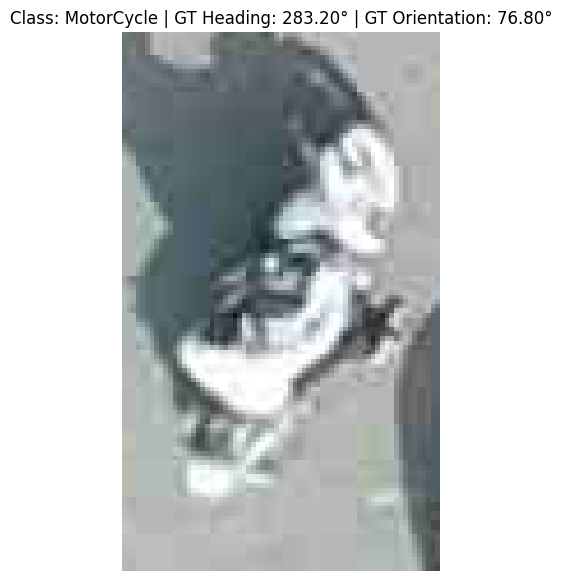

In [16]:
# =========================================================
# WEEK 3 - CELL 26
# DISPLAY SINGLE VEHICLE CROP
# =========================================================

plt.figure(
    figsize=(7, 7)
)


plt.imshow(
    cv2.cvtColor(
        single_crop,
        cv2.COLOR_BGR2RGB
    )
)


plt.title(
    f"Class: "
    f"{single_test_vehicle['class_name']} | "
    f"GT Heading: "
    f"{single_test_vehicle['heading']:.2f}° | "
    f"GT Orientation: "
    f"{single_test_vehicle['gt_orientation']:.2f}°"
)


plt.axis("off")

plt.show()

COMMON PREPROCESSING

The same preprocessing is applied to all three orientation-estimation methods.

Pipeline:

Vehicle crop
→ Grayscale
→ CLAHE contrast enhancement
→ Gaussian blur
→ Canny edge detection
→ Morphological closing

Only the final orientation-estimation method changes.

In [17]:
# =========================================================
# WEEK 3 - CELL 28
# COMMON PREPROCESSING
# =========================================================

def preprocess_vehicle(
    crop
):
    """
    Common preprocessing for PCA,
    Hough and Contour methods.
    """

    # Grayscale
    gray = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2GRAY
    )


    # Local contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )


    enhanced = clahe.apply(
        gray
    )


    # Gaussian blur
    blurred = cv2.GaussianBlur(
        enhanced,
        (5, 5),
        0
    )


    # Automatic Canny thresholds
    median_value = np.median(
        blurred
    )


    lower = int(
        max(
            0,
            0.66 * median_value
        )
    )


    upper = int(
        min(
            255,
            1.33 * median_value
        )
    )


    if upper <= lower:

        lower = 50
        upper = 150


    # Canny edge detection
    edges = cv2.Canny(
        blurred,
        lower,
        upper
    )


    # Morphological closing
    kernel = np.ones(
        (3, 3),
        dtype=np.uint8
    )


    edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )


    return {
        "gray": gray,
        "enhanced": enhanced,
        "blurred": blurred,
        "edges": edges
    }


single_processed = (
    preprocess_vehicle(
        single_crop
    )
)


print(
    "Common preprocessing completed."
)

Common preprocessing completed.


EDGE-MAP VERIFICATION

The common edge map is displayed before orientation estimation.

This is the same preprocessing output supplied to the classical orientation methods.

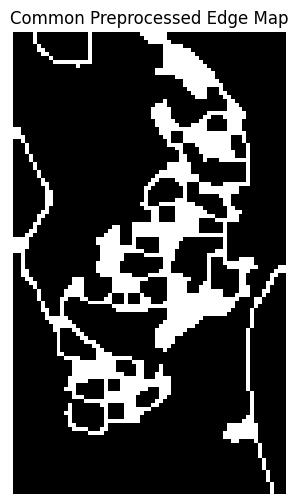

In [18]:
# =========================================================
# WEEK 3 - CELL 30
# DISPLAY EDGE MAP
# =========================================================

plt.figure(
    figsize=(8, 6)
)


plt.imshow(
    single_processed["edges"],
    cmap="gray"
)


plt.title(
    "Common Preprocessed Edge Map"
)


plt.axis("off")

plt.show()

VEHICLE CONTOUR SELECTION

Contours are extracted from the common edge map.

A likely vehicle contour is selected using:
• meaningful contour area
• proximity to the crop centre

This contour is used by the PCA and contour-based methods.

In [19]:
# =========================================================
# WEEK 3 - CELL 32
# FIND VEHICLE CONTOUR
# =========================================================

def find_vehicle_contour(
    edges
):
    """
    Select a likely vehicle contour
    from the edge map.
    """

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )


    if not contours:

        return None


    h, w = edges.shape

    image_area = (
        h * w
    )


    image_center = np.array([
        w / 2.0,
        h / 2.0
    ])


    candidates = []


    for contour in contours:

        area = cv2.contourArea(
            contour
        )


        # Reject very small regions
        if area < (
            0.01
            * image_area
        ):

            continue


        # Reject an almost-full crop contour
        if area > (
            0.95
            * image_area
        ):

            continue


        moments = cv2.moments(
            contour
        )


        if abs(
            moments["m00"]
        ) < 1e-8:

            continue


        cx = (
            moments["m10"]
            / moments["m00"]
        )


        cy = (
            moments["m01"]
            / moments["m00"]
        )


        distance = np.linalg.norm(
            np.array([
                cx,
                cy
            ])
            - image_center
        )


        centrality = (
            1.0
            / (1.0 + distance)
        )


        score = (
            math.log1p(area)
            * centrality
        )


        candidates.append(
            (
                score,
                contour
            )
        )


    if not candidates:

        return max(
            contours,
            key=cv2.contourArea
        )


    candidates.sort(
        key=lambda item: item[0],
        reverse=True
    )


    return candidates[0][1]


print(
    "Contour selection function ready."
)

Contour selection function ready.


METHOD 1 — PCA ORIENTATION ESTIMATION

PCA is used to estimate the principal direction of the selected vehicle contour.

Pipeline:

Vehicle crop
→ Common preprocessing
→ Vehicle contour
→ Contour points
→ PCA
→ Principal axis
→ Orientation angle
→ 0–90 degree orientation

In [20]:
# =========================================================
# WEEK 3 - CELL 34
# PCA ORIENTATION ESTIMATION
# =========================================================

def normalize_orientation(
    angle_deg
):
    """
    Convert an undirected angle into
    the 0-90 degree representation.
    """

    theta = (
        float(angle_deg)
        % 180.0
    )


    if theta > 90.0:

        theta = (
            180.0
            - theta
        )


    return theta


def pca_orientation(
    crop
):
    """
    Estimate vehicle orientation
    using PCA.
    """

    processed = (
        preprocess_vehicle(
            crop
        )
    )


    edges = processed[
        "edges"
    ]


    contour = find_vehicle_contour(
        edges
    )


    if contour is None:

        return np.nan


    points = contour.reshape(
        -1,
        2
    ).astype(
        np.float64
    )


    if len(points) < 5:

        return np.nan


    mean, eigenvectors, eigenvalues = (
        cv2.PCACompute2(
            points,
            mean=None
        )
    )


    principal_vector = (
        eigenvectors[0]
    )


    vx = float(
        principal_vector[0]
    )


    vy = float(
        principal_vector[1]
    )


    raw_angle = math.degrees(
        math.atan2(
            vy,
            vx
        )
    )


    orientation = (
        normalize_orientation(
            raw_angle
        )
    )


    return orientation

METHOD 2 — HOUGH TRANSFORM ORIENTATION ESTIMATION

The probabilistic Hough Transform is applied to the common edge image.

Detected line segments are converted into orientations.

Line length is used as a weight when estimating the dominant axial orientation.

In [21]:
# =========================================================
# WEEK 3 - CELL 36
# HOUGH TRANSFORM ORIENTATION ESTIMATION
# =========================================================

def hough_orientation(
    crop
):
    """
    Estimate vehicle orientation
    using the probabilistic Hough Transform.
    """

    processed = (
        preprocess_vehicle(
            crop
        )
    )


    edges = processed[
        "edges"
    ]


    h, w = edges.shape


    minimum_dimension = min(
        h,
        w
    )


    min_line_length = max(
        8,
        int(
            0.20
            * minimum_dimension
        )
    )


    max_line_gap = max(
        3,
        int(
            0.05
            * minimum_dimension
        )
    )


    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=15,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )


    if lines is None:

        return np.nan


    weighted_cos = 0.0
    weighted_sin = 0.0
    total_weight = 0.0


    for line in lines[:, 0]:

        x1, y1, x2, y2 = map(
            int,
            line
        )


        dx = (
            x2 - x1
        )


        dy = (
            y2 - y1
        )


        length = math.hypot(
            dx,
            dy
        )


        if length < min_line_length:

            continue


        angle_rad = math.atan2(
            dy,
            dx
        )


        # Axial angle:
        # theta and theta + 180 degrees
        # represent the same orientation.


        weighted_cos += (
            length
            * math.cos(
                2 * angle_rad
            )
        )


        weighted_sin += (
            length
            * math.sin(
                2 * angle_rad
            )
        )


        total_weight += length


    if total_weight == 0:

        return np.nan


    mean_angle_rad = (
        0.5
        * math.atan2(
            weighted_sin,
            weighted_cos
        )
    )


    orientation = (
        normalize_orientation(
            math.degrees(
                mean_angle_rad
            )
        )
    )


    return orientation

METHOD 3 — CONTOUR-BASED ORIENTATION ESTIMATION

The selected vehicle contour is fitted with a minimum-area rotated rectangle.

The orientation of the long axis of the fitted rectangle is used as the estimated vehicle orientation.

In [22]:
# =========================================================
# WEEK 3 - CELL 38
# CONTOUR-BASED ORIENTATION ESTIMATION
# =========================================================

def contour_orientation(
    crop
):
    """
    Estimate vehicle orientation from
    the minimum-area rectangle of the contour.
    """

    processed = (
        preprocess_vehicle(
            crop
        )
    )


    edges = processed[
        "edges"
    ]


    contour = find_vehicle_contour(
        edges
    )


    if contour is None:

        return np.nan


    rectangle = cv2.minAreaRect(
        contour
    )


    center, size, raw_angle = (
        rectangle
    )


    width, height = size


    if (
        width <= 0
        or
        height <= 0
    ):

        return np.nan


    # Select the orientation of the
    # rectangle's LONG axis.

    if width < height:

        long_axis_angle = (
            raw_angle
            + 90.0
        )

    else:

        long_axis_angle = raw_angle


    orientation = (
        normalize_orientation(
            long_axis_angle
        )
    )


    return orientation

SINGLE-IMAGE METHOD VALIDATION

The exact same vehicle crop is now given to:

1. PCA
2. Hough Transform
3. Contour-based method

Each prediction is compared with the same ground-truth orientation.

In [23]:
# =========================================================
# WEEK 3 - CELL 40
# RUN ALL THREE METHODS ON ONE VEHICLE
# =========================================================

gt = float(
    single_test_vehicle[
        "gt_orientation"
    ]
)


# PCA
pca_prediction = (
    pca_orientation(
        single_crop
    )
)


# Hough
hough_prediction = (
    hough_orientation(
        single_crop
    )
)


# Contour
contour_prediction = (
    contour_orientation(
        single_crop
    )
)


def calculate_error(
    prediction,
    ground_truth
):
    """
    Calculate absolute angular error
    for the 0-90 degree orientation.
    """

    if pd.isna(
        prediction
    ):

        return np.nan


    return abs(
        float(prediction)
        - float(ground_truth)
    )


one_image_results = pd.DataFrame({

    "Method": [
        "PCA",
        "Hough",
        "Contour"
    ],

    "Ground_Truth_Orientation": [
        gt,
        gt,
        gt
    ],

    "Predicted_Orientation": [
        pca_prediction,
        hough_prediction,
        contour_prediction
    ],

    "Angular_Error": [

        calculate_error(
            pca_prediction,
            gt
        ),

        calculate_error(
            hough_prediction,
            gt
        ),

        calculate_error(
            contour_prediction,
            gt
        )
    ]
})


display(
    one_image_results
)

,Method,Ground_Truth_Orientation,Predicted_Orientation,Angular_Error
0,PCA,76.8,72.510042,4.289958
1,Hough,76.8,82.442268,5.642268
2,Contour,76.8,86.308614,9.508614


SINGLE-IMAGE VISUAL COMPARISON

The estimated orientation from each method is displayed separately alongside the ground-truth orientation.

This visual test is used to verify that all three methods are operating correctly before processing 100 images.

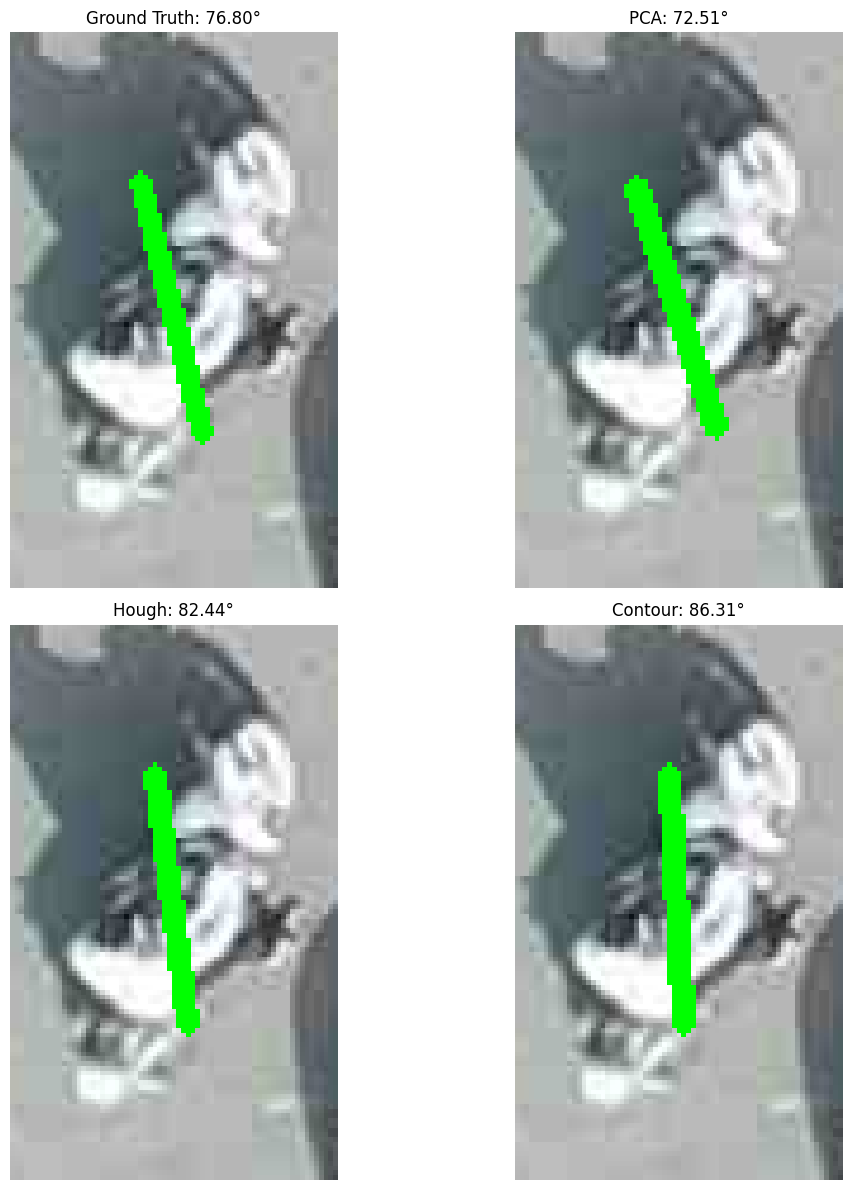

In [24]:
# =========================================================
# WEEK 3 - CELL 42
# VISUALIZE SINGLE-IMAGE RESULTS
# =========================================================

def draw_orientation_line(
    image,
    angle_deg
):
    """
    Draw an undirected orientation axis
    through the centre of the crop.
    """

    output = image.copy()


    if pd.isna(
        angle_deg
    ):

        return output


    h, w = output.shape[:2]


    center = (
        w // 2,
        h // 2
    )


    length = max(
        10,
        int(
            0.40
            * min(
                h,
                w
            )
        )
    )


    angle_rad = math.radians(
        float(angle_deg)
    )


    dx = math.cos(
        angle_rad
    )

    dy = math.sin(
        angle_rad
    )


    p1 = (
        int(
            center[0]
            - dx * length
        ),
        int(
            center[1]
            - dy * length
        )
    )


    p2 = (
        int(
            center[0]
            + dx * length
        ),
        int(
            center[1]
            + dy * length
        )
    )


    cv2.line(
        output,
        p1,
        p2,
        (0, 255, 0),
        3
    )


    return output


visual_data = [

    (
        "Ground Truth",
        gt
    ),

    (
        "PCA",
        pca_prediction
    ),

    (
        "Hough",
        hough_prediction
    ),

    (
        "Contour",
        contour_prediction
    )
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)


for ax, (
    method_name,
    angle
) in zip(
    axes.flatten(),
    visual_data
):

    visual = draw_orientation_line(
        single_crop,
        angle
    )


    visual_rgb = cv2.cvtColor(
        visual,
        cv2.COLOR_BGR2RGB
    )


    ax.imshow(
        visual_rgb
    )


    if pd.isna(angle):

        angle_text = "Failed"

    else:

        angle_text = (
            f"{angle:.2f}°"
        )


    ax.set_title(
        f"{method_name}: "
        f"{angle_text}"
    )


    ax.axis("off")


plt.tight_layout()

plt.show()

100-IMAGE EXPERIMENT

A fixed set of exactly 100 different training images is selected.

One valid difficulty-0 vehicle is selected from each image.

The same 100 vehicle crops will be evaluated using PCA, Hough Transform and Contour-based orientation estimation.

This ensures a fair comparison because every method receives exactly the same inputs.

In [25]:
# =========================================================
# WEEK 3 - CELL 44
# SELECT EXACTLY 100 DIFFERENT IMAGES
# =========================================================

TARGET_IMAGES = 100


rng = np.random.default_rng(
    2026
)


# Shuffle label files
shuffled_labels = list(
    all_label_members
)

rng.shuffle(
    shuffled_labels
)


selected_100 = []

used_image_stems = set()


# ---------------------------------------------------------
# Keep searching until exactly 100 valid images are found.
# We STOP immediately after 100.
# ---------------------------------------------------------

for label_member in tqdm(
    shuffled_labels,
    desc="Selecting 100 images"
):

    image_stem = Path(
        label_member
    ).stem


    # Ensure all selected images are different
    if image_stem in used_image_stems:

        continue


    # Read only this annotation
    raw_text = label_zip.read(
        label_member
    ).decode(
        "utf-8",
        errors="ignore"
    )


    _, vehicles = (
        parse_annotation_text(
            raw_text
        )
    )


    # Use complete vehicles
    valid_vehicles = [
        vehicle
        for vehicle in vehicles
        if vehicle["difficulty"] == 0
    ]


    if not valid_vehicles:

        continue


    # Use the first valid vehicle
    # from this image
    vehicle = valid_vehicles[0]


    selected_100.append({

        "image_stem":
            image_stem,

        "label_member":
            label_member,

        **vehicle
    })


    used_image_stems.add(
        image_stem
    )


    # STOP at 100
    if len(selected_100) >= TARGET_IMAGES:

        break


if len(selected_100) < TARGET_IMAGES:

    raise RuntimeError(
        f"Only {len(selected_100)} valid "
        f"images were found."
    )


week3_100_df = pd.DataFrame(
    selected_100
)


print(
    "\nExactly",
    len(week3_100_df),
    "images selected."
)


print(
    "\nVehicle class distribution:\n"
)


display(
    week3_100_df[
        "class_name"
    ]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
    .rename(
        "Number of Images"
    )
    .to_frame()
)

Selecting 100 images:   0%|          | 0/16571 [00:00<?, ?it/s]


Exactly 100 images selected.

Vehicle class distribution:



,Number of Images
class_name,
Auto3WCargo,3
AutoRicksaw,8
Bus,2
Container,3
Mixer,0
MotorCycle,30
PickUp,4
SUV,34
Sedan,7


FREEZE THE 100-IMAGE SAMPLE

The exact 100 selected images are saved before running the algorithms.

The same fixed sample will be used for all three orientation-estimation methods.

In [26]:
# =========================================================
# WEEK 3 - CELL 46
# SAVE FIXED 100-IMAGE SAMPLE
# =========================================================

WEEK3_DIR = Path(
    "/content/ECE501_Week3"
)


WEEK3_DIR.mkdir(
    parents=True,
    exist_ok=True
)


selected_100_file = (
    WEEK3_DIR
    / "week3_selected_100_images.csv"
)


columns_to_save = [
    "image_stem",
    "vehicle_id",
    "class_id",
    "class_name",
    "difficulty",
    "heading",
    "gt_orientation",
    "flight_height"
]


week3_100_df[
    columns_to_save
].to_csv(
    selected_100_file,
    index=False
)


print(
    "Fixed 100-image sample saved:"
)

print(
    selected_100_file
)

Fixed 100-image sample saved:
/content/ECE501_Week3/week3_selected_100_images.csv


100-IMAGE ORIENTATION ESTIMATION

For each of the 100 selected images:

1. Retrieve the corresponding training image.
2. Extract the selected vehicle using its OBB.
3. Preserve its original orientation.
4. Apply the common preprocessing.
5. Estimate orientation using PCA.
6. Estimate orientation using Hough Transform.
7. Estimate orientation using Contour-based estimation.
8. Compare all predictions with ground truth.
9. Calculate angular errors.
10. Store the complete result in a single CSV table.

In [29]:
# =========================================================
# WEEK 3 - CELL 48
# RUN PCA + HOUGH + CONTOUR ON 100 VEHICLES
# =========================================================

CROP_DIR = (
    WEEK3_DIR
    / "crops"
)


CROP_DIR.mkdir(
    parents=True,
    exist_ok=True
)


results = []

failures = []


for _, row in tqdm(
    week3_100_df.iterrows(),
    total=len(week3_100_df),
    desc="Processing 100 vehicles"
):

    image_stem = row[
        "image_stem"
    ]


    vehicle_id = int(
        row["vehicle_id"]
    )


    vehicle_uid = (
        f"{image_stem}"
        f"_vehicle_{vehicle_id}"
    )


    # -----------------------------------------------------
    # IMAGE LOOKUP
    # -----------------------------------------------------

    if image_stem not in image_lookup:

        failures.append({

            "vehicle_uid":
                vehicle_uid,

            "reason":
                "Image not found in train.zip"
        })

        continue


    try:

        # -------------------------------------------------
        # Read image
        # -------------------------------------------------

        image_member = (
            image_lookup[
                image_stem
            ]
        )


        raw = train_zip.read(
            image_member
        )


        image_array = np.frombuffer(
            raw,
            dtype=np.uint8
        )


        image = cv2.imdecode(
            image_array,
            cv2.IMREAD_COLOR
        )


        if image is None:

            raise ValueError(
                "Could not decode image."
            )


        # -------------------------------------------------
        # Extract vehicle crop
        # -------------------------------------------------

        crop = extract_vehicle_crop(
            image,
            row["obb_points"]
        )


        if crop is None:

            raise ValueError(
                "Vehicle crop extraction failed."
            )


        # -------------------------------------------------
        # Save crop
        # -------------------------------------------------

        crop_path = (
            CROP_DIR
            / f"{vehicle_uid}.jpg"
        )


        cv2.imwrite(
            str(crop_path),
            crop
        )


        # -------------------------------------------------
        # Ground truth
        # -------------------------------------------------

        gt = float(
            row["gt_orientation"]
        )


        # -------------------------------------------------
        # PCA
        # -------------------------------------------------

        try:

            pca_prediction = (
                pca_orientation(
                    crop
                )
            )

        except Exception:

            pca_prediction = np.nan


        # -------------------------------------------------
        # Hough
        # -------------------------------------------------

        try:

            hough_prediction = (
                hough_orientation(
                    crop
                )
            )

        except Exception:

            hough_prediction = np.nan


        # -------------------------------------------------
        # Contour
        # -------------------------------------------------

        try:

            contour_prediction = (
                contour_orientation(
                    crop
                )
            )

        except Exception:

            contour_prediction = np.nan


        # -------------------------------------------------
        # Angular errors
        # -------------------------------------------------

        pca_error = calculate_error(
            pca_prediction,
            gt
        )


        hough_error = calculate_error(
            hough_prediction,
            gt
        )


        contour_error = calculate_error(
            contour_prediction,
            gt
        )


        # -------------------------------------------------
        # Crop size
        # -------------------------------------------------

        crop_height = (
            crop.shape[0]
        )


        crop_width = (
            crop.shape[1]
        )


        # -------------------------------------------------
        # Image sharpness
        # -------------------------------------------------

        gray = cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2GRAY
        )


        sharpness = float(
            cv2.Laplacian(
                gray,
                cv2.CV_64F
            ).var()
        )


        # -------------------------------------------------
        # Save complete result
        # -------------------------------------------------

        results.append({

            "vehicle_uid":
                vehicle_uid,

            "image_stem":
                image_stem,

            "vehicle_id":
                vehicle_id,

            "class_id":
                int(
                    row["class_id"]
                ),

            "class_name":
                row["class_name"],

            "difficulty":
                int(
                    row["difficulty"]
                ),

            "gt_heading":
                float(
                    row["heading"]
                ),

            "gt_orientation":
                gt,

            "crop_width":
                crop_width,

            "crop_height":
                crop_height,

            "sharpness":
                sharpness,

            "pca_prediction":
                pca_prediction,

            "pca_error":
                pca_error,

            "hough_prediction":
                hough_prediction,

            "hough_error":
                hough_error,

            "contour_prediction":
                contour_prediction,

            "contour_error":
                contour_error,

            "crop_path":
                str(crop_path)
        })


    except Exception as error:

        failures.append({

            "vehicle_uid":
                vehicle_uid,

            "reason":
                str(error)
        })


week3_results_df = pd.DataFrame(
    results
)


failures_df = pd.DataFrame(
    failures
)


print(
    "\n=========================================="
)

print(
    "100-IMAGE EXPERIMENT COMPLETE"
)

print(
    "=========================================="
)


print(
    "Requested:",
    len(week3_100_df)
)


print(
    "Successfully processed:",
    len(week3_results_df)
)


print(
    "Complete failures:",
    len(failures_df)
)

Processing 100 vehicles:   0%|          | 0/100 [00:00<?, ?it/s]


100-IMAGE EXPERIMENT COMPLETE
Requested: 100
Successfully processed: 100
Complete failures: 0


WEEK 3 — FINAL 100-IMAGE ERROR TABLE

The 100 selected vehicle images were processed using the three conventional orientation-estimation methods:

1. PCA
2. Hough Transform
3. Contour-based method

For every vehicle, the table records the vehicle information, ground-truth orientation, estimated orientation from each method, and the corresponding angular error.

This table represents the main quantitative result of the Week-3 experiment.

In [30]:
# =========================================================
# WEEK 3 - CELL 50
# CREATE FINAL 100-IMAGE ERROR TABLE
# =========================================================

# Create a clean table containing only the
# information required for the Week-3 comparison.

error_table = week3_results_df[[
    "vehicle_uid",
    "image_stem",
    "vehicle_id",
    "class_id",
    "class_name",
    "difficulty",
    "gt_heading",
    "gt_orientation",
    "pca_prediction",
    "pca_error",
    "hough_prediction",
    "hough_error",
    "contour_prediction",
    "contour_error"
]].copy()


# Rename columns to make the CSV easier to read.

error_table = error_table.rename(columns={

    "vehicle_uid":
        "Vehicle_ID",

    "image_stem":
        "Image_ID",

    "vehicle_id":
        "Vehicle_Number",

    "class_id":
        "Class_ID",

    "class_name":
        "Vehicle_Class",

    "difficulty":
        "Difficulty",

    "gt_heading":
        "Ground_Truth_Heading_deg",

    "gt_orientation":
        "Ground_Truth_Orientation_deg",

    "pca_prediction":
        "PCA_Estimated_Orientation_deg",

    "pca_error":
        "PCA_Angular_Error_deg",

    "hough_prediction":
        "Hough_Estimated_Orientation_deg",

    "hough_error":
        "Hough_Angular_Error_deg",

    "contour_prediction":
        "Contour_Estimated_Orientation_deg",

    "contour_error":
        "Contour_Angular_Error_deg"
})


# Round numerical values for a clean report table.

numeric_columns = [
    "Ground_Truth_Heading_deg",
    "Ground_Truth_Orientation_deg",
    "PCA_Estimated_Orientation_deg",
    "PCA_Angular_Error_deg",
    "Hough_Estimated_Orientation_deg",
    "Hough_Angular_Error_deg",
    "Contour_Estimated_Orientation_deg",
    "Contour_Angular_Error_deg"
]


for column in numeric_columns:

    error_table[column] = (
        error_table[column]
        .round(2)
    )


# Display the complete table.

print(
    "Final Week-3 Error Table"
)

print(
    "Number of processed vehicles:",
    len(error_table)
)

display(
    error_table
)

Final Week-3 Error Table
Number of processed vehicles: 100


,Vehicle_ID,Image_ID,Vehicle_Number,Class_ID,Vehicle_Class,Difficulty,Ground_Truth_Heading_deg,Ground_Truth_Orientation_deg,PCA_Estimated_Orientation_deg,PCA_Angular_Error_deg,Hough_Estimated_Orientation_deg,Hough_Angular_Error_deg,Contour_Estimated_Orientation_deg,Contour_Angular_Error_deg
0,KNyT_zacV_LpYg_vehicle_1,KNyT_zacV_LpYg,1,5,MotorCycle,0,283.20,76.80,72.51,4.29,82.44,5.64,86.31,9.51
1,IwEd_XCYw_iwrB_vehicle_1,IwEd_XCYw_iwrB,1,0,Auto3WCargo,0,214.74,34.74,5.61,29.13,54.72,19.98,0.00,34.74
2,C2g2_vYbb_ihYH_vehicle_1,C2g2_vYbb_ihYH,1,7,SUV,0,239.58,59.58,50.14,9.44,69.57,9.99,52.43,7.15
3,gqbe_NCQI_MTLw_vehicle_1,gqbe_NCQI_MTLw,1,7,SUV,0,171.34,8.66,0.84,7.82,10.04,1.38,0.00,8.66
4,boDi_WlMN_s88Y_vehicle_1,boDi_WlMN_s88Y,1,9,Tanker,0,97.00,83.00,83.19,0.19,86.27,3.27,90.00,7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,mCA9_HWns_Z2vx_vehicle_1,mCA9_HWns_Z2vx,1,5,MotorCycle,0,352.46,7.54,11.72,4.18,9.74,2.20,8.88,1.34
96,ujAh_YrF6_ZxDC_vehicle_1,ujAh_YrF6_ZxDC,1,5,MotorCycle,0,22.86,22.86,30.34,7.48,29.27,6.41,57.34,34.48
97,snm2_JSHC_Pqwn_vehicle_1,snm2_JSHC_Pqwn,1,11,Trailer,0,317.00,43.00,47.07,4.07,34.09,8.91,43.81,0.81
98,qfLL_ZpzB_kbJe_vehicle_1,qfLL_ZpzB_kbJe,1,7,SUV,0,36.50,36.50,18.29,18.21,37.62,1.12,37.87,1.37


WEEK 3 — SAVE RESULTS TO GOOGLE DRIVE

The final 100-image error table is saved permanently to Google Drive.

The table contains:
• Image and vehicle identification
• Vehicle class
• Difficulty
• Ground-truth heading
• Ground-truth 0–90 degree orientation
• PCA prediction and angular error
• Hough prediction and angular error
• Contour prediction and angular error

This CSV will be used for later project analysis and reporting.

In [31]:
# =========================================================
# WEEK 3 - CELL 52
# SAVE FINAL ERROR TABLE TO GOOGLE DRIVE
# =========================================================

# Create Week-3 results folder in Drive

DRIVE_WEEK3_DIR = (
    DATA_DIR / "Week3_Results"
)

DRIVE_WEEK3_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Path for final error table

DRIVE_ERROR_TABLE = (
    DRIVE_WEEK3_DIR
    / "week3_100_image_error_table.csv"
)


# Save CSV directly to Google Drive

error_table.to_csv(
    DRIVE_ERROR_TABLE,
    index=False
)


print(
    "Week-3 error table saved successfully!"
)

print(
    "\nGoogle Drive location:"
)

print(
    DRIVE_ERROR_TABLE
)


# Verify the file exists

if DRIVE_ERROR_TABLE.exists():

    print(
        "\n✓ File verified in Google Drive."
    )

    print(
        "File size:",
        round(
            DRIVE_ERROR_TABLE.stat().st_size
            / 1024,
            2
        ),
        "KB"
    )

else:

    print(
        "\n✗ File was not found."
    )

Week-3 error table saved successfully!

Google Drive location:
/content/drive/MyDrive/ECE501_DRASHTI/Week3_Results/week3_100_image_error_table.csv

✓ File verified in Google Drive.
File size: 9.67 KB
